In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/encoded_data.csv")
df.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
1,2,70.70,151.65,1,0,0,0,1,1,0,...,0,0,0,0,0,0,1,0,1,0
2,8,99.65,820.50,1,0,0,0,1,1,0,...,0,1,0,1,0,0,1,0,1,0
3,28,104.80,3046.05,1,0,0,1,1,1,0,...,0,1,0,1,0,0,1,0,1,0
4,49,103.70,5036.30,1,1,0,0,1,1,0,...,0,1,0,1,0,0,1,0,0,0


In [2]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (7032, 31)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Tenure Months                           7032 non-null   int64  
 1   Monthly Charges                         7032 non-null   float64
 2   Total Charges                           7032 non-null   float64
 3   Churn Value                             7032 non-null   int64  
 4   Gender_Male                             7032 non-null   int64  
 5   Senior Citizen_Yes                      7032 non-null   int64  
 6   Partner_Yes                             7032 non-null   int64  
 7   Dependents_Yes                          7032 non-null   int64  
 8   Phone Service_Yes                       7032 non-null   int64  
 9   Multiple Lines_No phone service         7032 non-null   int64  
 10  Multiple Lines_Yes                      7032 

In [3]:
df.shape

(7032, 31)

In [4]:
df.columns.tolist()

['Tenure Months',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'Gender_Male',
 'Senior Citizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'Phone Service_Yes',
 'Multiple Lines_No phone service',
 'Multiple Lines_Yes',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Online Security_No internet service',
 'Online Security_Yes',
 'Online Backup_No internet service',
 'Online Backup_Yes',
 'Device Protection_No internet service',
 'Device Protection_Yes',
 'Tech Support_No internet service',
 'Tech Support_Yes',
 'Streaming TV_No internet service',
 'Streaming TV_Yes',
 'Streaming Movies_No internet service',
 'Streaming Movies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'Paperless Billing_Yes',
 'Payment Method_Credit card (automatic)',
 'Payment Method_Electronic check',
 'Payment Method_Mailed check']

In [5]:
# separating input features and target variable
X = df.drop("Churn Value", axis = 1)
y = df["Churn Value"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 30)
y shape: (7032,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

In [12]:
from sklearn.linear_model import LogisticRegression

# create the model
log_model = LogisticRegression(max_iter=5000)

# train the model
log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [13]:
y_pred = log_model.predict(X_test)
print(y_pred[:20])

[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]


In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8045486851457001
Precision: 0.6402266288951841
Recall: 0.6042780748663101
F1 Score: 0.6217331499312242

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



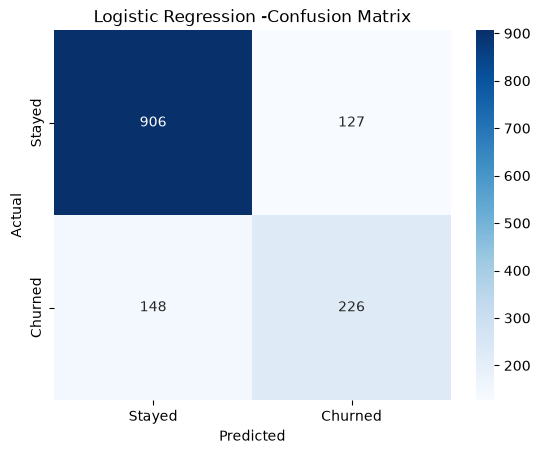

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression -Confusion Matrix")
plt.show()